In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os.path as osp
import os
from scipy.optimize import curve_fit

---

In [55]:
path = "results/parameter_sweep_20250915_230041"

# max_displacement_values = np.array([0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0])
max_displacement_values = np.array([0.2, 0.4, 0.6, 0.8, 1.0])
max_rotation_values = np.array([10, 30, 60, 90, 120, 150, 180])

energy_dict = {}
pressure_dict = {}

for max_displacement in max_displacement_values:
    for max_rotation in max_rotation_values:
        file_pattern = f"ions_dipole_disp_{max_displacement}_rot_{max_rotation}"
        file_path = None
        for folder in os.listdir(path):
            if folder.startswith(file_pattern):
                folder_path = osp.join(path, folder)
                break

        if folder_path is None:
            raise ValueError(f"File not found for max_displacement={max_displacement} and max_rotation={max_rotation}")

        df = pd.read_csv(osp.join(folder_path, "simulation_data.csv"))

        energy_dict[(max_displacement, max_rotation)] = df["energy_total"].to_numpy()
        pressure_dict[(max_displacement, max_rotation)] = df["pressure_total"].to_numpy()
steps = df["step"].to_numpy() * 1e-3

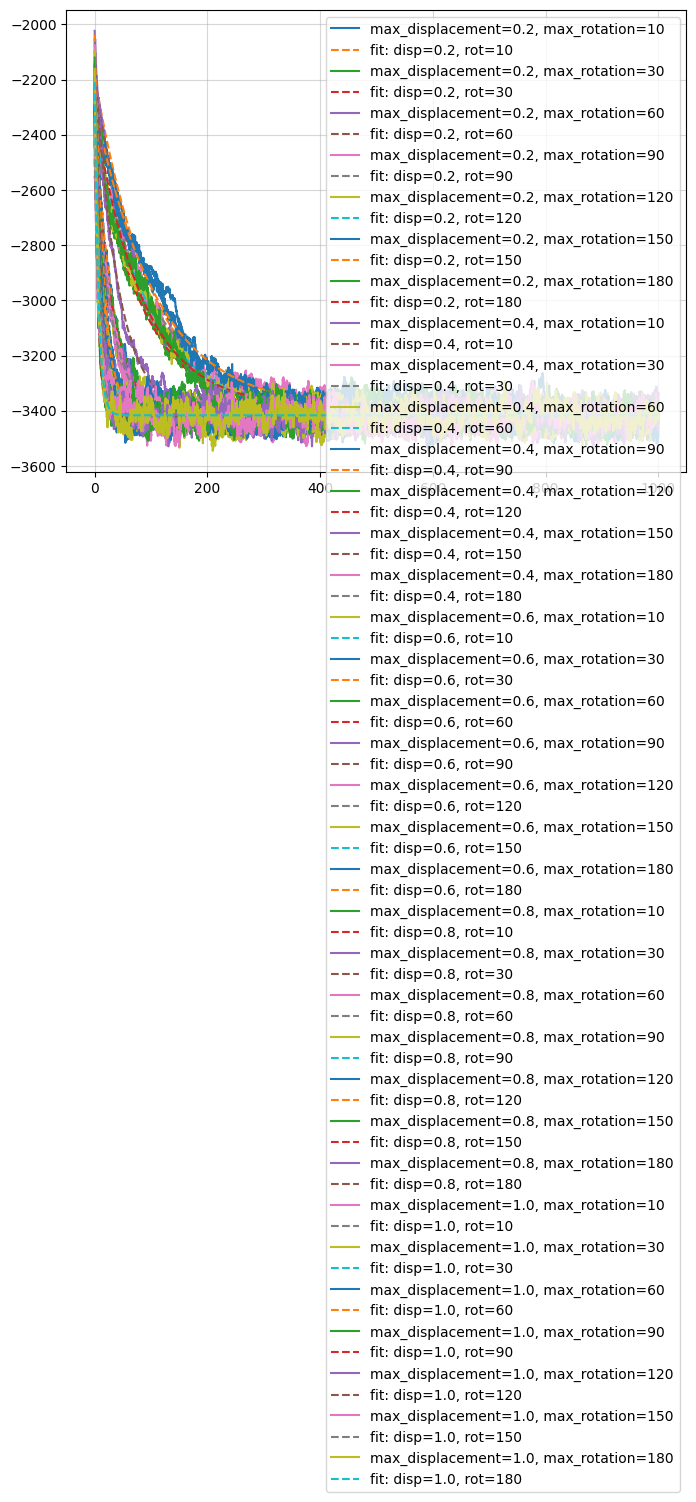

In [50]:
def exp_func(x, A, B, C):
    # Use np.clip to avoid overflow in the exponent
    return A * np.exp(np.clip(B * x, -700, 700)) + C

plt.figure(figsize=(8, 6))
plt.grid(alpha=0.5)

fit_results_dict = {}

for key, value in energy_dict.items():
    max_displacement, max_rotation = key
    plt.plot(steps, value, label=f"max_displacement={max_displacement}, max_rotation={max_rotation}")

    # Fit the data to A*exp(B*x) + C
    try:
        # Improved initial guesses based on user-provided info:
        # At zero, data ~ -2300; minimum energy ~ -3400; decay time ~ 0.4e+06
        C0 = -3400  # Asymptotic minimum
        A0 = value[0] - C0  # Initial amplitude
        B0 = -1.0 / 0.4e3   # Decay rate (negative, so exp decays over 0.4e6 steps)
        # Optionally, clip B0 to avoid overflow
        popt, pcov = curve_fit(
            exp_func, steps, value,
            p0=[A0, B0, C0],
            maxfev=10000,
            bounds=(
                [-np.inf, -np.inf, -np.inf],  # Lower bounds
                [np.inf, 0, np.inf]           # Upper bounds: B < 0 for decay
            )
        )
        fit_y = exp_func(steps, *popt)

        fit_results_dict[(max_displacement, max_rotation)] = popt
        plt.plot(steps, fit_y, '--', label=f"fit: disp={max_displacement}, rot={max_rotation}")
    except Exception as e:
        print(f"Fit failed for max_displacement={max_displacement}, max_rotation={max_rotation}: {e}")

plt.legend()
plt.show()

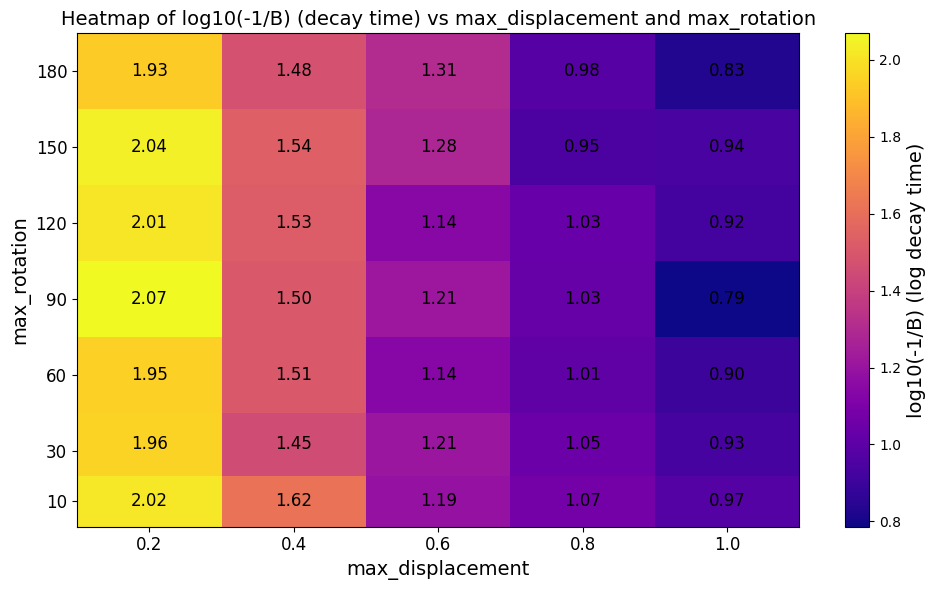

In [51]:
# Prepare data for heatmap in log scale (all values are negative)
import numpy as np

# Collect all unique max_displacement and max_rotation values
displacements = sorted(set([key[0] for key in fit_results_dict.keys()]))
rotations = sorted(set([key[1] for key in fit_results_dict.keys()]))

# Create mapping from value to index
disp_idx = {d: i for i, d in enumerate(max_displacement_values)}
rot_idx = {r: i for i, r in enumerate(max_rotation_values)}

# Initialize heatmap array
heatmap = np.full((len(max_rotation_values), len(max_displacement_values)), np.nan)

# Fill heatmap with log10(-1/B) values (since 1/B is negative)
for key, value in fit_results_dict.items():
    max_displacement, max_rotation = key
    A, B, C = value
    if B != 0:
        inv_B = 1.0 / B
        if inv_B < 0:
            heatmap[rot_idx[max_rotation], disp_idx[max_displacement]] = np.log10(-inv_B)
        else:
            heatmap[rot_idx[max_rotation], disp_idx[max_displacement]] = np.nan  # Only log negative values
    else:
        heatmap[rot_idx[max_rotation], disp_idx[max_displacement]] = np.nan  # Avoid division by zero

plt.figure(figsize=(10, 6))

# To handle non-uniform and non-integer tick positions, use pcolormesh with explicit edges
disp_vals = np.array(max_displacement_values)
rot_vals = np.array(max_rotation_values)

# Compute cell edges for displacements and rotations
def get_edges(vals):
    vals = np.array(vals)
    if len(vals) == 1:
        # Single value: make a cell of width 1 centered at the value
        return np.array([vals[0] - 0.5, vals[0] + 0.5])
    else:
        edges = (vals[1:] + vals[:-1]) / 2
        # Add left and right edges
        edges = np.concatenate(([vals[0] - (edges[0] - vals[0])], edges, [vals[-1] + (vals[-1] - edges[-1])]))
        return edges

disp_edges = get_edges(disp_vals)
rot_edges = get_edges(rot_vals)

# Use a different colormap, e.g., 'plasma'
mesh = plt.pcolormesh(
    disp_edges, rot_edges, heatmap,
    cmap='plasma', shading='auto'
)
cbar = plt.colorbar(mesh)
cbar.set_label("log10(-1/B) (log decay time)", fontsize=14)
plt.xlabel("max_displacement", fontsize=14)
plt.ylabel("max_rotation", fontsize=14)
plt.title("Heatmap of log10(-1/B) (decay time) vs max_displacement and max_rotation", fontsize=14)

# Set ticks at the center of each cell
plt.xticks(disp_vals, [str(v) for v in disp_vals], fontsize=12)
plt.yticks(rot_vals, [str(v) for v in rot_vals], fontsize=12)

# Add value labels to each cell, centered, using a single color (black)
for i, rot in enumerate(rot_vals):
    for j, disp in enumerate(disp_vals):
        val = heatmap[i, j]
        if not np.isnan(val):
            # Center of the cell
            x_center = (disp_edges[j] + disp_edges[j+1]) / 2
            y_center = (rot_edges[i] + rot_edges[i+1]) / 2
            plt.text(
                x_center, y_center, f"{val:.2f}",
                ha='center', va='center',
                color='black',
                fontsize=12
            )

plt.tight_layout()
plt.show()


In [56]:
mean_energy_dict = {}
std_energy_dict = {}

mean_pressure_dict = {}
std_pressure_dict = {}

for key, value in fit_results_dict.items():
    max_displacement, max_rotation = key
    A, B, C = value

    tau = -1 / B
    if 4 * tau > steps[-1]:
        print(f"tau = {tau} > steps[-1] = {steps[-1]} for max_displacement={max_displacement}, max_rotation={max_rotation}")

    id = np.argmin(np.abs(steps - 2 * tau))

    mean_energy_dict[(max_displacement, max_rotation)] = energy_dict[(max_displacement, max_rotation)][id:].mean()
    std_energy_dict[(max_displacement, max_rotation)] = energy_dict[(max_displacement, max_rotation)][id:].std()

    mean_pressure_dict[(max_displacement, max_rotation)] = pressure_dict[(max_displacement, max_rotation)][id:].mean()
    std_pressure_dict[(max_displacement, max_rotation)] = pressure_dict[(max_displacement, max_rotation)][id:].std()


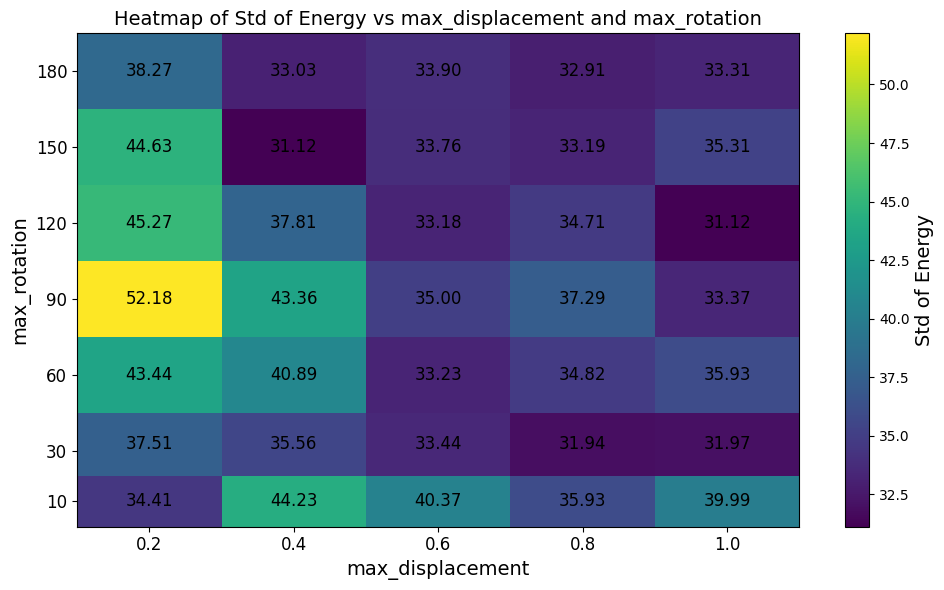

In [ ]:
# Prepare data for heatmap: std of energy
import numpy as np

# Collect all unique max_displacement and max_rotation values
displacements = sorted(set([key[0] for key in std_energy_dict.keys()]))
rotations = sorted(set([key[1] for key in std_energy_dict.keys()]))

# Create mapping from value to index
disp_idx = {d: i for i, d in enumerate(displacements)}
rot_idx = {r: i for i, r in enumerate(rotations)}

# Initialize heatmap array for std of energy
std_heatmap = np.full((len(rotations), len(displacements)), np.nan)

# Fill heatmap with std values
for key, value in std_energy_dict.items():
    max_displacement, max_rotation = key
    std_heatmap[rot_idx[max_rotation], disp_idx[max_displacement]] = value

plt.figure(figsize=(10, 6))

# Compute cell edges for displacements and rotations
def get_edges(vals):
    vals = np.array(vals)
    if len(vals) == 1:
        return np.array([vals[0] - 0.5, vals[0] + 0.5])
    else:
        edges = (vals[1:] + vals[:-1]) / 2
        edges = np.concatenate(([vals[0] - (edges[0] - vals[0])], edges, [vals[-1] + (vals[-1] - edges[-1])]))
        return edges

disp_vals = np.array(displacements)
rot_vals = np.array(rotations)
disp_edges = get_edges(disp_vals)
rot_edges = get_edges(rot_vals)

# Use a colormap, e.g., 'viridis'
mesh = plt.pcolormesh(
    disp_edges, rot_edges, std_heatmap,
    cmap='viridis', shading='auto'
)
cbar = plt.colorbar(mesh)
cbar.set_label("Std of Energy", fontsize=14)
plt.xlabel("max_displacement", fontsize=14)
plt.ylabel("max_rotation", fontsize=14)
plt.title("Heatmap of Std of Energy vs max_displacement and max_rotation", fontsize=14)

# Set ticks at the center of each cell
plt.xticks(disp_vals, [str(v) for v in disp_vals], fontsize=12)
plt.yticks(rot_vals, [str(v) for v in rot_vals], fontsize=12)

# Add value labels to each cell, centered, using a single color (black)
for i, rot in enumerate(rot_vals):
    for j, disp in enumerate(disp_vals):
        val = std_heatmap[i, j]
        if not np.isnan(val):
            x_center = (disp_edges[j] + disp_edges[j+1]) / 2
            y_center = (rot_edges[i] + rot_edges[i+1]) / 2
            plt.text(
                x_center, y_center, f"{val:.2f}",
                ha='center', va='center',
                color='black',
                fontsize=12
            )

plt.tight_layout()
plt.show()


In [57]:
for key, value in mean_pressure_dict.items():
    max_displacement, max_rotation = key
    mean_pressure = mean_pressure_dict[(max_displacement, max_rotation)]
    std_pressure = std_pressure_dict[(max_displacement, max_rotation)]

    print(f"max_displacement={max_displacement}, max_rotation={max_rotation}, mean_pressure={mean_pressure}, std_pressure={std_pressure}")

max_displacement=0.2, max_rotation=10, mean_pressure=1.3112541662035868, std_pressure=0.0027687140001012513
max_displacement=0.2, max_rotation=30, mean_pressure=1.3096346043956044, std_pressure=0.0029758635114630772
max_displacement=0.2, max_rotation=60, mean_pressure=1.3099547430133656, std_pressure=0.002154313113205562
max_displacement=0.2, max_rotation=90, mean_pressure=1.3103857938871473, std_pressure=0.003307063882206861
max_displacement=0.2, max_rotation=120, mean_pressure=1.3100665342741935, std_pressure=0.002824417343314976
max_displacement=0.2, max_rotation=150, mean_pressure=1.309157770422535, std_pressure=0.0025709394947081897
max_displacement=0.2, max_rotation=180, mean_pressure=1.308251348397204, std_pressure=0.002375616693279707
max_displacement=0.4, max_rotation=10, mean_pressure=1.309631900010904, std_pressure=0.002246295801869433
max_displacement=0.4, max_rotation=30, mean_pressure=1.310636750556321, std_pressure=0.002339332411135285
max_displacement=0.4, max_rotation=

In [ ]:
# Prepare data for heatmap: std of energy
import numpy as np

# Collect all unique max_displacement and max_rotation values
displacements = sorted(set([key[0] for key in std_energy_dict.keys()]))
rotations = sorted(set([key[1] for key in std_energy_dict.keys()]))

# Create mapping from value to index
disp_idx = {d: i for i, d in enumerate(displacements)}
rot_idx = {r: i for i, r in enumerate(rotations)}

# Initialize heatmap array for std of energy
std_heatmap = np.full((len(rotations), len(displacements)), np.nan)

# Fill heatmap with std values
for key, value in std_energy_dict.items():
    max_displacement, max_rotation = key
    std_heatmap[rot_idx[max_rotation], disp_idx[max_displacement]] = value

plt.figure(figsize=(10, 6))

# Compute cell edges for displacements and rotations
def get_edges(vals):
    vals = np.array(vals)
    if len(vals) == 1:
        return np.array([vals[0] - 0.5, vals[0] + 0.5])
    else:
        edges = (vals[1:] + vals[:-1]) / 2
        edges = np.concatenate(([vals[0] - (edges[0] - vals[0])], edges, [vals[-1] + (vals[-1] - edges[-1])]))
        return edges

disp_vals = np.array(displacements)
rot_vals = np.array(rotations)
disp_edges = get_edges(disp_vals)
rot_edges = get_edges(rot_vals)

# Use a colormap, e.g., 'viridis'
mesh = plt.pcolormesh(
    disp_edges, rot_edges, std_heatmap,
    cmap='viridis', shading='auto'
)
cbar = plt.colorbar(mesh)
cbar.set_label("Std of Energy", fontsize=14)
plt.xlabel("max_displacement", fontsize=14)
plt.ylabel("max_rotation", fontsize=14)
plt.title("Heatmap of Std of Energy vs max_displacement and max_rotation", fontsize=14)

# Set ticks at the center of each cell
plt.xticks(disp_vals, [str(v) for v in disp_vals], fontsize=12)
plt.yticks(rot_vals, [str(v) for v in rot_vals], fontsize=12)

# Add value labels to each cell, centered, using a single color (black)
for i, rot in enumerate(rot_vals):
    for j, disp in enumerate(disp_vals):
        val = std_heatmap[i, j]
        if not np.isnan(val):
            x_center = (disp_edges[j] + disp_edges[j+1]) / 2
            y_center = (rot_edges[i] + rot_edges[i+1]) / 2
            plt.text(
                x_center, y_center, f"{val:.2f}",
                ha='center', va='center',
                color='black',
                fontsize=12
            )

plt.tight_layout()
plt.show()
